In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , r2_score


In [69]:
data = pd.read_csv('/content/housing.csv')

In [70]:
print(data)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                  41          880           129.0   
1        -122.22     37.86                  21         7099          1106.0   
2        -122.24     37.85                  52         1467           190.0   
3        -122.25     37.85                  52         1274           235.0   
4        -122.25     37.85                  52         1627           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                  25         1665           374.0   
20636    -121.21     39.49                  18          697           150.0   
20637    -121.22     39.43                  17         2254           485.0   
20638    -121.32     39.43                  18         1860           409.0   
20639    -121.24     39.37                  16         2785           616.0   

       population  households  median_income ocean_

In [71]:
print(data.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64


In [72]:
import math
median_bedrooms = math.floor(data.total_bedrooms.median())
data.total_bedrooms.fillna(median_bedrooms,inplace=True)
print(data.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
median_house_value    0
dtype: int64


/tmp/ipykernel_1315/4166441161.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.total_bedrooms.fillna(median_bedrooms,inplace=True)


In [73]:

X = data.drop('median_house_value',axis=1)
Y = data['median_house_value']

In [74]:
# Perform one-hot encoding on 'ocean_proximity'
X = pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True)

In [75]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [76]:
# Now apply the StandardScaler to the one-hot encoded X
Scaler = StandardScaler()
X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled = Scaler.transform(X_test)

In [77]:


linear_model = LinearRegression()
ridge_model = Ridge()
tree_model = DecisionTreeRegressor(random_state=42)

linear_model.fit(X_train_scaled, Y_train)
ridge_model.fit(X_train_scaled, Y_train)
tree_model.fit(X_train_scaled, Y_train)


DecisionTreeRegressor(random_state=42)

RMSE: 2487165.0239676987
R2 Score: -471.06558861893245


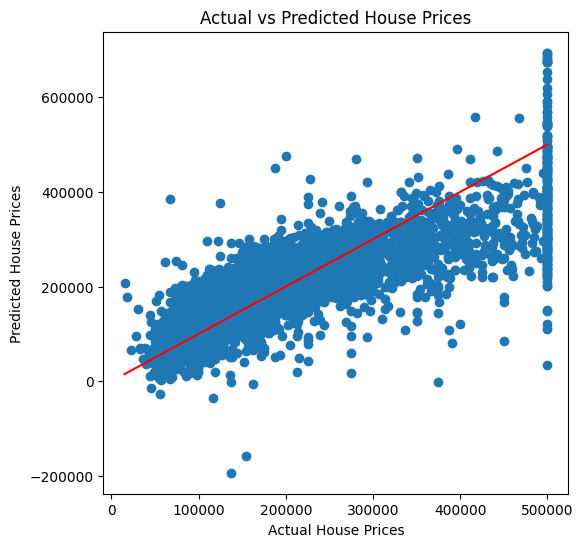

In [78]:


best_model.fit(X_train, Y_train)
Y_pred_linear = linear_model.predict(X_test_scaled)
Y_pred_ridge = ridge_model.predict(X_test_scaled)
Y_pred_tree = tree_model.predict(X_test_scaled)

rmse_linear= np.sqrt(mean_squared_error(Y_test, Y_pred_linear))
r2_linear = r2_score(Y_test, Y_pred_linear)

rmse_ridge = np.sqrt(mean_squared_error(Y_test, Y_pred_ridge))
r2_ridge = r2_score(Y_test, Y_pred_ridge)

rmse_tree = np.sqrt(mean_squared_error(Y_test, Y_pred_tree))
r2_tree = r2_score(Y_test, Y_pred_tree)



print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

plt.figure(figsize=(6,6))
plt.scatter(Y_test, y_pred_linear)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.title("Actual vs Predicted House Prices")

plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    color="red"
)

plt.show()

In [79]:
result_data = pd.DataFrame(columns=['Model', 'RMSE', 'R2 Score'])
result_data

,Model,RMSE,R2 Score


In [80]:
result_data.loc[len(result_data)] = [
    'Linear Regression',
    rmse_linear,
    r2_linear
]

result_data.loc[len(result_data)] = [
    'Ridge Regression',
    rmse_ridge,
    r2_ridge
]

result_data.loc[len(result_data)] = [
    'Decision Tree',
    rmse_tree,
    r2_tree
]

print(result_data)


               Model          RMSE  R2 Score
0  Linear Regression  70060.521845  0.625424
1   Ridge Regression  70057.416870  0.625457
2      Decision Tree  69680.877724  0.629473
